##Problems with LangChain

🏥 Multi-Tool Health Care Assistant Agent
🤖 Autonomous Decision-Making Engine based on SQL + RAG + Web Search + Python tool data analysis

[Code file link ](https://colab.research.google.com/drive/1SM0EqjnXRAD3cmbyoh5d7NsygTuk01NB)

# LangGraph

##Package Requirements

In [101]:
%%writefile requirements.txt
langchain
langgraph
langchain_community
langchain-community
langchain-core
langchain-openai
langchain-text-splitters
langchain-chroma
gradio
tavily
pypdf
tiktoken
arxiv
langsmith
wikipedia

Overwriting requirements.txt


In [102]:
!pip install -r requirements.txt

# Example-1: Basic LangGraph

In [1]:
#Check the version of langgraph
!pip show langgraph

Name: langgraph
Version: 1.2.4
Summary: Building stateful, multi-actor applications with LLMs
Home-page: https://docs.langchain.com/oss/python/langgraph/overview
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: langchain-core, langgraph-checkpoint, langgraph-prebuilt, langgraph-sdk, pydantic, xxhash
Required-by: langchain


In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph

# Step 1: Define the state
class BankState(TypedDict):
    logged_in: bool
    balance: int


# Step 2: Create Node Functions
def login(state):
    print("Checking password...")

    state["logged_in"] = True
    return state


def check_balance(state):
    print("Fetching balance...")

    state["balance"] = 1000
    return state

In [ ]:
# Step 3: Create Workflow Graph
workflow = StateGraph(BankState)

# Add nodes
workflow.add_node("login_node", login)
workflow.add_node("balance_node", check_balance)

# Connect nodes
workflow.add_edge("login_node", "balance_node")

# Starting and Ending node
workflow.set_entry_point("login_node")
workflow.set_finish_point("balance_node")

# Compile graph
app = workflow.compile()

In [ ]:
# Step 4: Display the graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
# Step 5: Run the graph
result = app.invoke({
    "logged_in": False,
    "balance": 0
})

print(result)

#LAB Exercise – Basic Graph Creation

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph

# State shared across workflow
class FoodOrderState(TypedDict):
    order_confirmed: bool
    food_prepared: bool
    delivery_status: str

# Node 1: Confirm order
def confirm_order(state):
    print("Confirming food order...")
    state["order_confirmed"] = True
    return state


# Node 2: Prepare food
def prepare_food(state):
    print("Preparing food...")
    state["food_prepared"] = True
    return state


# Node 3: Deliver food
def deliver_food(state):
    print("Delivering food...")
    state["delivery_status"] = "Delivered"
    return state

In [ ]:
# Create graph
workflow = StateGraph(FoodOrderState)

# Add nodes
workflow.add_node("confirm_node", confirm_order)
workflow.add_node("prepare_node", prepare_food)
workflow.add_node("delivery_node", deliver_food)

# Connect nodes
workflow.add_edge("confirm_node", "prepare_node")
workflow.add_edge("prepare_node", "delivery_node")

# Start and end points
workflow.set_entry_point("confirm_node")
workflow.set_finish_point("delivery_node")

# Compile
app = workflow.compile()
app

In [ ]:
# Execute workflow
result = app.invoke({
    "order_confirmed": False,
    "food_prepared": False,
    "delivery_status": ""
})

print(result)

#Example-2: Conditional Edges

##Step 1: Define the state

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, END


class ATMState(TypedDict):
    acct_balance: int
    withdraw_amount: int
    is_authenticated: bool
    transaction_successful: bool

print(ATMState.__annotations__)

In [ ]:
initial_state = {
    "acct_balance": 1000,
    "withdraw_amount": 200,
    "is_authenticated": False,
    "transaction_successful": False
}
print(initial_state)

##Step-2: Create Node Functions

In [ ]:
#Node-1
def authenticate(state:ATMState):
  print("Authenticating user...")
  #Simulate PIN Check
  state["is_authenticated"] = True
  return state

print("State After Authentication", authenticate(initial_state))

In [ ]:
#Node-2
def check_balance(state:ATMState):
  print("Checking balance...")
  if state["acct_balance"] >= state["withdraw_amount"]:
    state["transaction_successful"] = True
  else:
    state["transaction_successful"] = False
  return state

print("State After Checking Balance", check_balance(initial_state))
print("State After Checking Balance", check_balance(authenticate(initial_state)))

In [ ]:
#Node3A
def deduct_money(state:ATMState):
  print("Deducting money...")
  state["acct_balance"] = state["acct_balance"]-state["withdraw_amount"]
  state["transaction_successful"] = True
  return state

print("State After Deducting Money", deduct_money(initial_state))


In [ ]:
#Node3B
def reject_transaction(state:ATMState):
  print("Rejecting transaction...")
  state["transaction_successful"] = False
  return state

print("State After Rejecting Transaction", reject_transaction(initial_state))

## Step-3: Define Edges [Flow Logic]

In [ ]:
#Routing Function
def decide_next(state:ATMState):
  if state["transaction_successful"]==True:
    return "deduct"
  return "reject"
print("Next step based on decision:", decide_next(initial_state))

In [ ]:
workflow = StateGraph(ATMState)

#Adding Nodes
workflow.add_node("authenticate", authenticate)
workflow.add_node("check_balance", check_balance)
workflow.add_node("deduct_money", deduct_money)
workflow.add_node("reject_transaction", reject_transaction)

#set Start Point
workflow.set_entry_point("authenticate")

#Define Eges
workflow.add_edge("authenticate", "check_balance")

#conditional edge
workflow.add_conditional_edges("check_balance", decide_next, {
    "deduct": "deduct_money",
    "reject": "reject_transaction"
})

#End Points
workflow.add_edge("deduct_money", END)
workflow.add_edge("reject_transaction", END)

#Compile the graph
app = workflow.compile()

## Step-4: Draw the Graph

In [ ]:
#Display the Graph using Ipython's display capabilities
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

## Step-5: Run the Graph

In [ ]:
result = app.invoke({
    "acct_balance": 1000,
    "withdraw_amount": 200,
    "is_authenticated": False,
    "transaction_successful": False
})

print(result)

In [ ]:
result = app.invoke({
    "acct_balance": 1000,
    "withdraw_amount": 2000,
    "is_authenticated": False,
    "transaction_successful": False
})

print(result)

#LAB Exercise – Conditional Edges

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

class TicketState(TypedDict):
    issue_type: str
    assigned_team: str
    ticket_status: str


initial_state = {
    "issue_type": "technical",
    "assigned_team": "",
    "ticket_status": ""
}

In [ ]:
# Node 1: Classify issue
def classify_issue(state: TicketState):
    print("Classifying customer issue...")

    if state["issue_type"] == "technical":
        state["assigned_team"] = "technical_team"
    else:
        state["assigned_team"] = "billing_team"
    return state


# Node 2A: Assign to technical team
def assign_technical_team(state: TicketState):
    print("Assigning to technical team...")
    state["ticket_status"] = "Assigned to Technical Team"
    return state


# Node 2B: Assign to billing team
def assign_billing_team(state: TicketState):
    print("Assigning to billing team...")
    state["ticket_status"] = "Assigned to Billing Team"
    return state


In [ ]:
# Routing function
def decide_ticket_path(state: TicketState):
    if state["assigned_team"] == "technical_team":
        return "technical"
    return "billing"

In [ ]:
# Graph
workflow = StateGraph(TicketState)

workflow.add_node("classify_issue", classify_issue)
workflow.add_node("assign_technical_team", assign_technical_team)
workflow.add_node("assign_billing_team", assign_billing_team)

workflow.set_entry_point("classify_issue")

workflow.add_conditional_edges(
    "classify_issue",
    decide_ticket_path,
    {
        "technical": "assign_technical_team",
        "billing": "assign_billing_team"
    }
)

workflow.add_edge("assign_technical_team", END)
workflow.add_edge("assign_billing_team", END)

app = workflow.compile()
app

In [ ]:
result = app.invoke(initial_state)
print(result)

#Example-3:LLM Node

In [ ]:
#!pip install langchain_community

## API Keys

In [ ]:
from langchain_classic.llms import OpenAI, Cohere
import os
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
os.environ["COHERE_API_KEY"] = userdata.get('COHERE_API_KEY')

In [ ]:
llm=OpenAI()
result=llm.invoke("What is FIRE number in personal finance?")
print(result)

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [ ]:
#State
class app_state(TypedDict):
    user_question: str
    answer: str

#Sample State
sample_state=app_state(user_question="What is the IKIGAI?", answer="")
print(sample_state)

In [ ]:
#LLM Node
def llm_node(state: app_state):
    llm = OpenAI()
    result = llm.invoke(state["user_question"])
    state["answer"] = result
    return state

print(llm_node(app_state(sample_state)))

In [ ]:
#Build the Graph
workflow = StateGraph(app_state)
workflow.add_node("llm_node", llm_node)

workflow.add_edge(START, "llm_node")
workflow.add_edge("llm_node", END)

app=workflow.compile()

In [ ]:
#Draw the graph
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
#Run the Graph
sample_state1=app_state(user_question="What is the IKIGAI?", answer="")
sample_state2=app_state(user_question="How to start a presentation?", answer="")

result1 = app.invoke(sample_state1)
print(result1)
result2 = app.invoke(sample_state2)
print(result2)

## Chat Interface in Gradio (optional)

In [ ]:
#!pip install gradio

In [ ]:
#Chat Interface with Gradio
import gradio as gr

def chatbot(user_message, history):
  input_state = {
      "user_question": user_message,
      "answer": ""
    }
  result = app.invoke(input_state)
  return result["answer"]

demo = gr.ChatInterface(
    fn=chatbot,
    title="LangGraph Chatbot"
)
demo.launch()


#Example-4: AI Agent using external tools

In [ ]:
!pip install tavily

## Tavily Serach Tool

In [ ]:
!pip install langchain_community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults
from google.colab import userdata
import os
os.environ["TAVILY_API_KEY"] = userdata.get('Tavely_Api_Key')

search_tool=TavilySearchResults(max_results=3)

#Quick testing of the tool setup
result=search_tool.invoke("Latest updates on AI")
print(result)

/tmp/ipykernel_8312/3549931276.py:6: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool=TavilySearchResults(max_results=3)


[{'title': 'Google AI announcements from April 2026', 'url': 'https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-april-2026', 'content': '## Bullet points\n\n Check out "The latest AI news we announced in April" for Google\'s newest tech updates.\n Google Cloud introduced powerful new tools and chips to help businesses build AI agents.\n You can now create professional videos for free using the new Google Vids suite.\n New coding tools like Learn Mode in Colab act as your personal programming tutor.\n Google is using AI to improve healthcare access and help students with test prep.\n\n## Basic explainer [...] ## Basic explainer\n\nGoogle announced a bunch of new AI tools in April to help people work, study and create more easily. They launched features like a free video generator, a personal coding tutor and advanced research assistants. These updates aim to make AI more helpful for everything from school projects to professional business tasks. Google is also using 

In [ ]:
!pip install langchain-openai

## LLM & Tool Binding

In [ ]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI()

#bind_tools() helps in deciding which tool to pick-up based on the input
tools=[search_tool]
llm_with_tools=llm.bind_tools(tools)

## Define State & Nodes

In [ ]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

class agent_state(TypedDict):
    messages: Annotated[list,add_messages]

#class agent_state(TypedDict):
#    messages: List    This works, but doesn't keep all the messages

In [ ]:
def llm_node(state: agent_state):
    response = llm_with_tools.invoke(state["messages"])
    state["messages"].append(response)
    return state

def tools_node(state: agent_state):
  all_tools=[search_tool]
  return ToolNode(tools=all_tools)

##Define the Graph

In [ ]:
all_tools=[search_tool]

agent_workflow=StateGraph(agent_state)
agent_workflow.add_node("llm_node", llm_node)
agent_workflow.add_node("tools", tools_node)

agent_workflow.add_edge(START, "llm_node")
agent_workflow.add_conditional_edges("llm_node", tools_condition, "tools")
agent_workflow.add_edge("tools", "llm_node")
agent_workflow.add_edge("llm_node", END)

agent_app=agent_workflow.compile()

#Draw the agent workflow
display(Image(agent_app.get_graph().draw_mermaid_png()))

##results

In [ ]:
result=agent_app.invoke(
    {
        "messages": [{"role": "user", "content": "What is the latest update on AI?"}]
    }
)
#print(result) #this contains all the messages
print(result["messages"][-1].content)

In [ ]:
#pretty print
from pprint import pprint
pprint(result)

In [ ]:
#pretty print
pprint(result["messages"][-1].content)

##Chat Interface with Gradio

In [ ]:
#Chat Interface with Gradio
import gradio as gr

def chatbot(user_message:str, history):
  result=agent_app.invoke(
    {
        "messages": [{"role": "user", "content": user_message}]
    })
  return str(result["messages"][-1].content)

gr.ChatInterface(fn=chatbot, title="LangGraph Agent Chatbot").launch()

In [2]:
# practice with travely
!pip install tavily

In [4]:
from langchain_community.tools.tavily_search import TavilySearchResults
from google.colab import userdata
import os
os.environ["TAVILY_API_KEY"] = userdata.get('Tavely_Api_Key')

search_tool=TavilySearchResults(max_results=3)

/tmp/ipykernel_3378/1265901677.py:6: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool=TavilySearchResults(max_results=3)


In [5]:
results= search_tool.invoke("latest updates on AI")
print(results)

[{'title': 'Google AI announcements from April 2026', 'url': 'https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-april-2026', 'content': '## Basic explainer\n\nGoogle announced a bunch of new AI tools in April to help people work, study and create more easily. They launched features like a free video generator, a personal coding tutor and advanced research assistants. These updates aim to make AI more helpful for everything from school projects to professional business tasks. Google is also using this tech to improve healthcare and language translation for everyone. [...] ## Bullet points\n\n Check out "The latest AI news we announced in April" for Google\'s newest tech updates.\n Google Cloud introduced powerful new tools and chips to help businesses build AI agents.\n You can now create professional videos for free using the new Google Vids suite.\n New coding tools like Learn Mode in Colab act as your personal programming tutor.\n Google is using AI to improve hea

In [ ]:
######### NOw build the grapgh with langraph############

In [7]:


from langchain_openai import ChatOpenAI
os.environ["OPENAI_API_KEY"] = userdata.get('OpenAI_API_key')
llm = ChatOpenAI()

#now bind the tool with llm
tools= [search_tool]
llm_with_tool = llm.bind_tools(tools)


# define the state
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import Annotated
from langgraph.prebuilt import ToolNode, tools_condition



class agent_state(TypedDict):
  messages : Annotated[list,add_messages]

# define Nodes
def llm_node(state: agent_state):
  response = llm_with_tool.invoke(state["messages"])
  # update the state
  state["messages"].append(response)
  return state

def tools_node(state: agent_state):
  all_tools = [search_tool]
  return ToolNode(tools=all_tools)

#Build the graph


agent_workflow = StateGraph(agent_state)

# add the node
agent_workflow.add_node("llm_node",llm_node)
agent_workflow.add_node("tools", tools_node)

# make the edges
agent_workflow.add_edge(START, "llm_node")
# make the conditionl edge
agent_workflow.add_conditional_edges("llm_node", tools_condition, "tools")

# add the edges
agent_workflow.add_edge("tools", "llm_node")
agent_workflow.add_edge("llm_node", END)
# agent_app = agent_workflow.compile()

# # draw the graph
# from IPython.display import display, Image
# display(Image(agent_app.get_graph().draw_mermaid_png()))


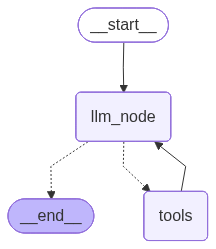

In [ ]:
agent_app

In [ ]:
## lets test the travely

sample_question= "waht is the latest news of Nifty 50? "
result= agent_app.invoke(
    {
        "messages": [{"role": "user", "content": sample_question}]
    }
)

In [ ]:
print(result["messages"][-1].content)


The latest news of Nifty 50 can be found on TradingView. You can visit the following link to access the news: [Nifty 50 Index Today - Chart and News - TradingView](https://www.tradingview.com/symbols/NSE-NIFTY)


In [ ]:
# now make the gardio app
import gradio as gr

def chatbot(user_message:str, history):
  result=agent_app.invoke(
    {
        "messages": [{"role": "user", "content": user_message}]
    })
  return str(result["messages"][-1].content)

demo = gr.ChatInterface(fn=chatbot, title="LangGraph Agent Chatbot")

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


In [ ]:
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a825ef764fa13cb34a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [8]:
# now add meemory to existing sysytme

from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
agent_app=agent_workflow.compile(checkpointer = memory)

In [69]:
config1 = {"configurable":{"thread_id": "1"}}
result1=agent_app.invoke(
    {
        "messages": [{"role": "user", "content": "What is the latest news in India?"}]
    },config=config1
)

In [72]:
print (result['messages'][-1].content)

The previous question was asking for a description of agentic AI in five lines.


In [74]:
config2 = {"configurable":{"thread_id": "02"}}
result2= agent_app.invoke(
    {
        "messages": [{"role": "user", "content": " black tea recipe in short "}]
    },config=config2
)

In [75]:
print (result2['messages'][-1].content)

Here is a short black tea recipe for you:

1. Boil water and pour it over the black tea leaves to agitate them.
2. Let the tea brew for a few minutes to infuse.
3. Remove the tea leaves or tea bag.
4. Serve and enjoy your black tea!

You can find more detailed recipes and variations at the following links:
1. [Lipton - Black Tea Recipe](https://www.lipton.com/us/en/world-of-tea/how-to-brew-black-tea)
2. [Hackberry Tea - Black Tea Brewing 101](https://www.hackberrytea.com/blogs/tea-education/tea-brewing-101-black-tea)
3. [Teabloom - 4 Amazing Black Tea Recipes](https://www.teabloom.com/blog/learn-how-to-make-black-tea-4-amazing-recipes)


In [77]:
config3 = {"configurable":{"thread_id": "3"}}
result= agent_app.invoke(
    {
      "messages": [{"role": "user", "content": "5 lines for agentic AI "}]
    },config=config3
)

In [78]:
print(result["messages"][-1].content)

1. Agentic AI refers to advanced AI systems capable of autonomous decision-making and action, setting goals, planning, and executing tasks with minimal human intervention.
2. These AI systems operate with a higher degree of autonomy and employ AI agents to perform specific tasks independently.
3. Agentic AI revolutionizes industries by automating complex processes, optimizing workflows, and handling tasks with minimal human oversight.
4. Benefits of agentic AI include increased efficiency, enhanced problem-solving, improved productivity, and scalability across various business functions.
5. Despite challenges such as ensuring data quality, integration with legacy systems, and governance issues, agentic AI offers significant potential for transforming business operations.


In [87]:
resulttt= agent_app.invoke(
    {
      "messages": [{"role": "user", "content": "what was previous question? "}]
    },config= config1
)
print(resulttt["messages"][-1].content)

The previous question was about providing the latest news in India.


#Example-5: Agent with Memory

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

## Add a checkpointer

In [ ]:
agent_app=agent_workflow.compile(checkpointer = memory)
display(Image(agent_app.get_graph().draw_mermaid_png()))

In [ ]:
config1 = {"configurable":{"thread_id": "1"}}
result=agent_app.invoke(
    {
        "messages": [{"role": "user", "content": "Who is the new CM of Tamilnadu?"}]
    },config=config1
)
print(result["messages"][-1].content)

In [ ]:
result=agent_app.invoke(
    {
        "messages": [{"role": "user", "content": "What was my previous question"}]
    },config=config1
)
print(result["messages"][-1].content)

## New thread_id

In [ ]:
config2 = {"configurable":{"thread_id": "2"}}
result=agent_app.invoke(
    {
        "messages": [{"role": "user", "content": "What is the latest news in India?"}]
    },config=config2
)
print(result["messages"][-1].content)

In [ ]:
result=agent_app.invoke(
    {
        "messages": [{"role": "user", "content": "What was my previous question?"}]
    },config=config1
)
print(result["messages"][-1].content)

In [ ]:
result=agent_app.invoke(
    {
        "messages": [{"role": "user", "content": "What was my previous question?"}]
    },config=config2
)
print(result["messages"][-1].content)

In [ ]:
#Chat Interface with Gradio
import gradio as gr

def chatbot(user_message:str, history):
  result=agent_app.invoke(
    {
        "messages": [{"role": "user", "content": user_message}]
    },config=config
    )
  return str(result["messages"][-1].content)

gr.ChatInterface(fn=chatbot, title="LangGraph Agent Chatbot").launch()

#LAB Exercise – Wikipedia Agent

In [ ]:
#!pip install wikipedia

In [ ]:
#Tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wiki_api = WikipediaAPIWrapper(top_k_results=5)
wiki_tool = WikipediaQueryRun(api_wrapper=wiki_api)

In [ ]:
# LLM & Tool Binding
from langchain_openai import ChatOpenAI
llm=ChatOpenAI()


tools=[wiki_tool]
llm_with_tools=llm.bind_tools(tools)

In [ ]:
#State
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import StateGraph, START, END

class agent_state(TypedDict):
    messages: Annotated[list,add_messages]

In [ ]:
#Nodes
def llm_node(state: agent_state):
    response = llm_with_tools.invoke(state["messages"])
    state["messages"].append(response)
    return state

def tools_node(state: agent_state):
  all_tools=[wiki_tool]
  return ToolNode(tools=all_tools)

In [ ]:
#Graph
agent_workflow=StateGraph(agent_state)
agent_workflow.add_node("llm_node", llm_node)
agent_workflow.add_node("tools", tools_node)

agent_workflow.add_edge(START, "llm_node")
agent_workflow.add_conditional_edges("llm_node", tools_condition, "tools")
agent_workflow.add_edge("tools", "llm_node")
agent_workflow.add_edge("llm_node", END)

agent_app=agent_workflow.compile()

#Draw the agent workflow
agent_app

In [ ]:
#Invoke
result=agent_app.invoke(
    {
        "messages": [{"role": "user", "content": "Donald Trump Education"}]
    }
)
#print(result) #this contains all the messages
from pprint import pprint
pprint(result["messages"][-1].content)

In [ ]:
#Memory Checkpoint
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
agent_app=agent_workflow.compile(checkpointer = memory)

In [ ]:
agent_app=agent_workflow.compile(checkpointer = memory)

In [ ]:
#Invoke with memory config
config = {"configurable":{"thread_id": "1"}}
result=agent_app.invoke(
    {
        "messages": [{"role": "user", "content": "Mahatma Gandhi"}]
    },config=config
)

In [ ]:
result=agent_app.invoke(
    {
        "messages": [{"role": "user", "content": "What was my previous question?"}]
    },config=config
)

In [ ]:
print(result["messages"][-1].content)

# **Parctice**:\\

> Add blockquote



In [104]:
## stsrat with wekipedia agent
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wiki_api = WikipediaAPIWrapper(top_k_results=5)
wiki_tool = WikipediaQueryRun(api_wrapper=wiki_api)

# bind the llm with tool
from langchain_openai import ChatOpenAI
llm=ChatOpenAI()

tools=[wiki_tool]
llm_with_tools=llm.bind_tools(tools)

In [112]:
# now start with building agent
# start with state define
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

class agent_state(TypedDict):
  messages: Annotated [list, add_messages]

# define the  nodes
def llm_node(state:agent_state):
  response = llm_with_tools.invoke(state["messages"])
  # update the state
  state["messages"].append(response)
  return state

def tools_node(state:agent_state):
  all_tools=[wiki_tool]
  return ToolNode(tools=all_tools)

In [113]:
# now make the graph with edges
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

agent_workflow=StateGraph(agent_state)

# add the node
agent_workflow.add_node("llm_node", llm_node)
agent_workflow.add_node("tools", tools_node)

# add the edges
agent_workflow.add_edge(START, "llm_node")
agent_workflow.add_conditional_edges("llm_node", tools_condition, "tools")

In [114]:
# now ake the graph with memory
from langgraph.checkpoint.memory import MemorySaver

memory= MemorySaver()
agent_app =agent_workflow.compile(checkpointer=memory)

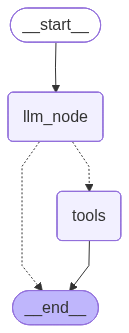

In [108]:
# show the grapgh
agent_app

In [115]:
# make the diferent thread for invke the app
config1 = {"configurable":{"thread_id": "1"}}
config2 = {"configurable":{"thread_id": "2"}}
config3 = {"configurable":{"thread_id": "3"}}

result1  =agent_app.invoke(
    {
        "messages": [{"role": "user", "content": " 4 lines on Mahatma Gandhi"}]
    },config=config1
)

print(result1["messages"][-1].content)
###########################################################
result2  =agent_app.invoke(
    {
        "messages": [{"role": "user", "content": "4 lines on donald trump"}]
    },config=config2
)

print(result2["messages"][-1].content)
##################################################################
result3  =agent_app.invoke(
    {
        "messages": [{"role": "user", "content": "4 lines about MS dhoni"}]
    },config=config3
)

print(result3["messages"][-1].content)


Page: Mahatma Gandhi
Summary: Mohandas Karamchand Gandhi (; GAHN-dee; 2 October 1869 – 30 January 1948) was an Indian lawyer, anti-colonial nationalist and political ethicist who employed nonviolent resistance to lead the successful campaign for India's independence from British rule, and to later inspire movements for civil rights and freedom across the world. The honorific Mahātmā (Sanskrit: "great-souled", "venerable"), first applied to him in 1914 in South Africa, is now used throughout the world.
Born and raised in a Hindu family in coastal Gujarat, Gandhi was trained in the law at the Inner Temple in London and was called to the bar at the age of 22. After two uncertain years in India, where he was unable to start a successful law practice, Gandhi moved to South Africa in 1893 to represent an Indian merchant in a lawsuit. He went on to live in South Africa for the next 21 years. Here, Gandhi raised a family and first employed nonviolent resistance in a campaign for civil rights. 

In [124]:
## check the memory and thread

result =agent_app.invoke(
    {
        "messages": [{"role": "user", "content":"waht was my last question to you ?"}]
    },config=config3
)

print(result["messages"][-1].content)

Your last question to me was "waht was my last question to you ?"


#Example-6: RAG Agent

In [ ]:
# Install:
#!pip install -U langgraph "langchain[openai]" langchain-community langchain-text-splitters langchain-chroma pypdf tiktoken

In [ ]:
import os
from typing import Annotated, TypedDict
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.messages import AnyMessage, HumanMessage
from langchain_core.tools.retriever import create_retriever_tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

In [ ]:
#API Keys
import os
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

## RAG Steps

In [ ]:
# 1. Load Health Insurance PDF
PDF_PATH = "https://raw.githubusercontent.com/venkatareddykonasani/Datasets/master/Health_Insurance_Plan/Health%20Companion-Health%20Insurance%20Plan_GEN617.pdf"
loader = PyPDFLoader(PDF_PATH)
docs = loader.load()
#print(docs[0])

# 2. Split into chunks
splitter = RecursiveCharacterTextSplitter(
    chunk_size=700,
    chunk_overlap=100
)
chunks = splitter.split_documents(docs)
#print(chunks[0])

# 3. Create Embeddings and Store in Vector DB
embeddings = OpenAIEmbeddings()
vector_db = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name="health_insurance_policy"
)

# 4. Create Retriever
retriever = vector_db.as_retriever(
    search_kwargs={"k": 4}
)
print(
    retriever.invoke("What is the waiting period for pre-existing diseases?")
)

## RAG as Tool

In [ ]:
# 5. Create the RAG Tool
rag_tool = create_retriever_tool(
    retriever,
    name="search_health_policy",
    description=(
        "Search the Health Companion health insurance policy document. "
        "Use this tool for questions about benefits, exclusions, waiting periods, "
        "claims procedure, co-pay, renewal, cancellation, ambulance cover, "
        "domiciliary treatment, and policy definitions."
    )
)
tools = [rag_tool]


# 6. Create LLM with Tool Binding
llm = ChatOpenAI()
llm_with_tools = llm.bind_tools(tools)


##Graph

In [ ]:
# 7. Define LangGraph State
class agent_state(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [ ]:
# 8. LLM Node
from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage

def llm_node(state: agent_state):
    system_prompt = SystemMessage(
        content="""
        You are a helpful health insurance policy assistant.
        You have access to a RAG tool named search_health_policy.
        Use the tool whenever the user asks about the Health Companion policy,
        including benefits, exclusions, waiting periods, claims, documents,
        co-pay, renewal, cancellation, and definitions.
        Answer only from the retrieved policy content.
        Keep the answer clear and concise.

        If the information is not found in the retrieved content, say:
        "I could not find this information in the policy document."
        """
    )

    messages = [system_prompt] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

#testing
result=llm_node(agent_state(messages=[]))
print(result)

In [ ]:
# 9. Tool Node
rag_tool_node=ToolNode(tools=[rag_tool])
print(rag_tool_node)

In [ ]:
# 10. Build LangGraph Workflow
workflow = StateGraph(agent_state)

workflow.add_node("llm_node", llm_node)
workflow.add_node("tools", rag_tool_node)

workflow.add_edge(START, "llm_node")
workflow.add_conditional_edges("llm_node", tools_condition, "tools")
workflow.add_edge("tools", "llm_node")
workflow.add_edge("llm_node", END)

app = workflow.compile()

In [ ]:
#11. Draw the graph
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
# 12. Ask One Question
question = "What is the waiting period for pre-existing diseases?"

result = app.invoke({
    "messages": [HumanMessage(content=question)]
})

print(result["messages"][-1].content)

In [ ]:
# 12. Ask One Question
question = "What is capital of India?"

result = app.invoke({
    "messages": [HumanMessage(content=question)]
})

print(result["messages"][-1].content)

In [ ]:
test_questions = [
    "What is covered under in-patient treatment?",
    "What is the waiting period for pre-existing conditions?",
    "Are pre-hospitalization expenses covered?",
    "Are post-hospitalization expenses covered?",
    "Is ambulance expense covered?",
    "What is domiciliary treatment?",
    "Is dental treatment covered?",
    "What documents are required for reimbursement claim?",
    "What is the co-pay rule for insured persons aged 65 or above?",
    "What is the free look cancellation period?"
]


for i, question in enumerate(test_questions, start=1):
    print("\n" + "=" * 80)
    print(f"TEST CASE {i}: {question}")
    print("=" * 80)

    response = app.invoke({
        "messages": [HumanMessage(content=question)]
    })

    print(response["messages"][-1].content)